# MAGIC dataset

## Import libraries and load MAGIC dataset

In [40]:
import math
import time
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import shap
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, auc
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
#from sklearn.calibration import CalibratedClassifierCV
#from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import joblib

We use the [MAGIC dataset](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope), a benchmark Machine learning binary classification task.

Each sample presents 10 geometrical features calculated from an individual (preprocessed) image of the hadronic "shower" recorded (in UV wavelength) by a ground-based telescope. (Typically, the image of a shower after some pre-processing is an elongated cluster). The task consists in classifying each shower (sample) as either caused by a high-energy gamma ray (signal) or a generic cosmic ray (background) colliding with particles in Earth's upper atmosphere. (All samples in this datasets are generated via Monte Carlo methods, and SNR is higher than in real life as to make the classification task easier).

In [2]:
def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",", names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
    ])
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.iloc[:, 0:10].values # Get first two columns as the input
    Y = data_train.iloc[:, 10].values # Get the third column as the label
    Y[Y=="g"]=1
    Y[Y=="h"]=0
    Y = Y.astype(int)
    return X,Y

# Load the dataset
X, Y = load_dataset("https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data")

# Division between test and train dataset
rng = rnd.Random(42)
idx = list(range(X.shape[0]))
test_idx = rng.sample(idx, int(X.shape[0]*0.25))
train_idx = [i for i in idx if i not in test_idx]
X_training = X[train_idx]
X_test  = X[test_idx]
Y_training = Y[train_idx]
Y_test  = Y[test_idx]

# Validation set definition
idx = list(range(X_training.shape[0]))
val_idx = rng.sample(idx, int(X_training.shape[0]*0.25))
train_idx = [i for i in idx if i not in val_idx]
X_val  = X_training[val_idx]
X_training = X_training[train_idx]
Y_val  = Y_training[val_idx]
Y_training = Y_training[train_idx]

In [99]:
ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1) # unbalance between samples of different classes

In [100]:
print(1/ratio) # optimal value of scale_pos_weight (see later)

1.8691338160364708


## Hyperparameters optimization for boosted forest models

### Random forest classifier for baseline comparison

In [40]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_training, Y_training)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_clean_rf=roc_auc_score(Y_test, y_prob_rf)
acc_clean_rf=accuracy_score(Y_test, y_pred_rf)
err_clean_rf=1-acc_clean_rf

print(f"RANDOM FOREST BASELINE (default params)")
print(f"ROC AUC:  {roc_auc_clean_rf:.4f}")
print(f"Accuracy: {acc_clean_rf:.4f}")
print(f"0-1 Loss: {err_clean_rf:.4f}")

RANDOM FOREST BASELINE (default params)
ROC AUC:  0.9310
Accuracy: 0.8793
0-1 Loss: 0.1207


### Gradient Boost

Standard gradient boosting is a tree-based binary classification model that uses _boosting_, _i.e._ it sequentially adds decision trees, each correcting the residuals of the previous ensemble. 

It offers classic hyperparameters that control complexity and speed:
* `n_estimators`: number of boosting stages (trees). More trees increase capacity but may overfit
* `learning_rate`: multiplicative factor (step size) that shrinks the contribution of each new tree before adding it to the ensemble; lower values demand more iterations but often generalize better`
* `max_depth`: maximum depth of each tree; deeper trees capture more interactions but overfit easily
* `subsample`: fraction of samples used for fitting each tree (stochastic gradient boosting). Values < 1.0 add randomness and can improve generalization
* `max_features`: fraction of features considered when looking for the best split
* `min_samples_split` and `min_samples_leaf`: minimum number of samples required to split an internal node or to be at a leaf node; both act as regularizers
* `class_weight`: to account for imbalance between classes.

We optimize these using Optuna (see below for the explanation) with 5‑fold stratified cross validation (CV) using 0-1 loss, and evaluate using ROC‑AUC score (see below). 

Note that for this problem we use ROC-AUC score (_Receiver Operating Characteristic - Area Under Curve_), a metric for binary classifiers.
It is defined as the area under the curve of true positives rate as a function of false positive rates; therefore, it penalizes false positives. In our case this is necessary, as classifying background as signal is considered worse, from a scientific point of view, than missing out on a real signal.
ROC-AUC varies from 0 to 1, 1 with 1 being perfect classification and 0.5 a random guess.

In practice, for tree models, given a set of predicted probabilities of the sample belonging to class 1 (which range continuously from 0 to 1), and the corresponding true labels of the samples, this curve is computed by varying the _decision threshold_ of the model, _i.e._ the threshold above which a sample is classified as belonging to class 1 (and not to class 0), for the simple reason that by doing so the false positive rate can change from 0 to 1.

In [35]:
def objective(trial):
    #scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.5, 1.5, log=True) # note: defined by us
    
    params = {
        'loss': 'log_loss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),          # reduced range
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20)#,
        #'class_weight': {0: 1.0, 1: scale_pos_weight},   

        # early stopping using loss - no simple way to use ROCAUC here
        'validation_fraction': 0.1,   # hold out 10% of each fold's training data
        'n_iter_no_change': 10,       # stop if no improvement for 10 iterations
        'tol': 1e-4,                  # minimum required improvement
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]
        model = GradientBoostingClassifier(**params)
        model.fit(X_tr, y_tr)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
    return np.mean(scores)

study_gbm = optuna.create_study(direction='maximize')

In [38]:
i=time.time()
study_gbm.optimize(objective, n_trials=50, show_progress_bar=True)   # fewer trials, fast convergence
f=time.time()
elapsed=f-i
print(f"Training completed in {elapsed:.1f} seconds.")

# Final training with best params + early stopping
best_gbm = GradientBoostingClassifier(
    loss='log_loss',
    random_state=42,
    validation_fraction=0.2,
    n_iter_no_change=10,        # stop early if no gain
    tol=1e-4,
    **study_gbm.best_params
)
best_gbm.fit(X_training, Y_training)

y_pred_gbm = best_gbm.predict(X_test)
y_prob_gbm = best_gbm.predict_proba(X_test)[:, 1]
roc_auc_clean_gbm=roc_auc_score(Y_test, y_prob_gbm)
print(f"GradientBoosting Test AUC: {roc_auc_clean_gbm:.4f}")

roc_auc_clean_gbm=roc_auc_score(Y_test, y_prob_gbm)

  0%|          | 0/30 [00:00<?, ?it/s]

1629.331264257431
GradientBoosting Test AUC: 0.9303


#### One-at-a-time search (?), 0-1 loss metric

```python
base_params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # equivalent to colsample_bytree=1.0
    'random_state': 42
}

# Parameters to test
params_to_test = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': [0.5, 0.7, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}


results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        model = GradientBoostingClassifier(**current_params)

        # 0-1 loss
        scores_acc = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='accuracy')
        scores_error = 1 - scores_acc

        means.append(scores_error.mean())
        stds.append(scores_error.std())

    results[param_name] = {'values': param_values, 'means': means, 'stds': stds}
    print("Done.")
# Plot
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Gradient Boosting Hyperparameter Analysis (0-1 Loss)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    ax.errorbar(data['values'], data['means'], yerr=data['stds'], fmt='-o', color='seagreen', ecolor='lightgray')
    ax.set_title(f'Effect of {param_name}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Mean 0-1 Loss')
    ax.grid(True, alpha=0.3)

    min_idx = np.argmin(data['means'])
    ax.annotate(f'Min: {data['means'][min_idx]:.4f}',
                xy=(data['values'][min_idx], data['means'][min_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center', color='green')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Final training
print("\nCOMBINING BEST PARAMETERS FOR GRADIENT BOOSTING")
best_params_final = base_params.copy()

for param_name, data in results.items():
    best_idx = np.argmin(data['means'])
    best_params_final[param_name] = data['values'][best_idx]
    print(f" - {param_name}: {data['values'][best_idx]}")

# Final training
final_model_gb = GradientBoostingClassifier(**best_params_final)
final_model_gb.fit(X_training, Y_training)
gb_bestparams= best_params_final.copy()
# Evaluation on Test Set
y_pred = final_model_gb.predict(X_test)
test_acc = accuracy_score(Y_test, y_pred)
print(f"FINAL TEST PERFORMANCE")
print(f"Accuracy: {test_acc:.4f}")
print(f"0-1 Loss: {1 - test_acc:.4f}")
```

### XGBoost

XGBoost is a boosted tree-based classification model that, as an improvement of standard Gradient Boosting, makes use of regularization, pruning, and second derivatives of the loss function (for evaluating the best split), along with other algorithmic improvements aimed at improving classification accuracy.

With regard to computational complexity, training is made much faster by parallel evaluation of all features, histogram-based splitting (_i.e._ continuous features are discretised by means of a certain number of bins), cache-friendly storage of intermediate results, and the fact that the code is written in C++ (instead of standard Python / CPython like Gradient Boost).

The hyperparameters involved in this model are:

- `max_depth`: same as before (GradientBoost)
- `min_child_weight`: parameter to regulate the minimum amount of points needed to add another node to the decision tree; regulates overfitting by avoiding to split over very small groups of points (same as `min_samples_split` in GradientBoost)
- `learning rate`: same as before
- `n_estimators`: samea as before
- `subsample` and `colsample_bytree`: percentage of rows (samples) or of columns (features) used by each tree, with a similar concept used in random forests with _bagging_. Same to, respectively, `subsample` and `max_features` in GradientBoost
- `gamma`: parameter to regulate _pruning_; with a high value the code will favor a simpler solution rather then a slightly more accurate one
- `reg_lambda`: parameter to regulate model complexity - it is the multiplicative constant of the L-2 regularization term
- `scale_pos_weight`: weight for the positive class; compensates for class imbalance by up-weighting the minority class

#### Performance with basic hyperparameters

In [4]:
# Parameters configuration
model = xgb.XGBClassifier(
    booster="gbtree",            # weak learner used as a base
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,                 # depth of trees
    subsample=0.8,               # 80% of rows
    colsample_bytree=0.8,        # 80% of columns
    scale_pos_weight=ratio,      # parameter that accounts for the inbalance of classes
    objective='binary:logistic', # goal of the model
    n_jobs=-1,                   # uses all cpu cores
    eval_metric='auc',           # metric used
    early_stopping_rounds=50,    # number of iteration that takes to stop if there are no significant improvements
    tree_method="hist",
    enable_categorical=True
)

In [5]:
# Training
model.fit(
    X_training, Y_training,
    eval_set=[(X_training, Y_training), (X_val, Y_val)], # evaluate also (but not only) on training set to have better understanding 
    verbose=100
)

[0]	validation_0-auc:0.86468	validation_1-auc:0.87610
[100]	validation_0-auc:0.94745	validation_1-auc:0.93822
[200]	validation_0-auc:0.96501	validation_1-auc:0.94164
[300]	validation_0-auc:0.97578	validation_1-auc:0.94229
[307]	validation_0-auc:0.97638	validation_1-auc:0.94246


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [6]:
# Evaluation
y_pred_basic_xgb = model.predict(X_test)
y_prob_basic_xgb = model.predict_proba(X_test)[:, 1]
roc_auc_clean_basic_xgb=roc_auc_score(Y_test, y_prob_basic_xgb)

In [7]:
print("Classification Report")
print(classification_report(Y_test, y_pred_basic_xgb))
print(f"ROC AUC Score: {roc_auc_clean_basic_xgb:.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1681
           1       0.90      0.92      0.91      3074

    accuracy                           0.88      4755
   macro avg       0.87      0.86      0.87      4755
weighted avg       0.88      0.88      0.88      4755

ROC AUC Score: 0.9308


#### Performance analysis for different hyperparameters - one-at-a-time search
Strategy (simplistic): change one parameter at a time, keep others as the default; use K-fold cross validation.

##### ROC-AUC metric

In [41]:
# Base parameters
base_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'verbosity': 0,
    # Defaults for parameters we aren't testing
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

# Parameters to analyze
params_to_test = {
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'n_estimators': [100, 300, 500, 800, 1000]
}


results = {} # To store the results

In [42]:
# setting up optimized library for K folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [43]:

for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        # Update params
        current_params = base_params.copy()
        current_params[param_name] = value        # uses default parameters for the rest and changes only one parameter

        # Train & CV
        model = xgb.XGBClassifier(**current_params)
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    # Save data for plotting
    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")


Testing gamma... Done.
Done.ng reg_lambda... 
Done.ng learning_rate... 
Done.ng subsample... 
Done.ng colsample_bytree... 
Done.ng max_depth... 
Done.ng n_estimators... 


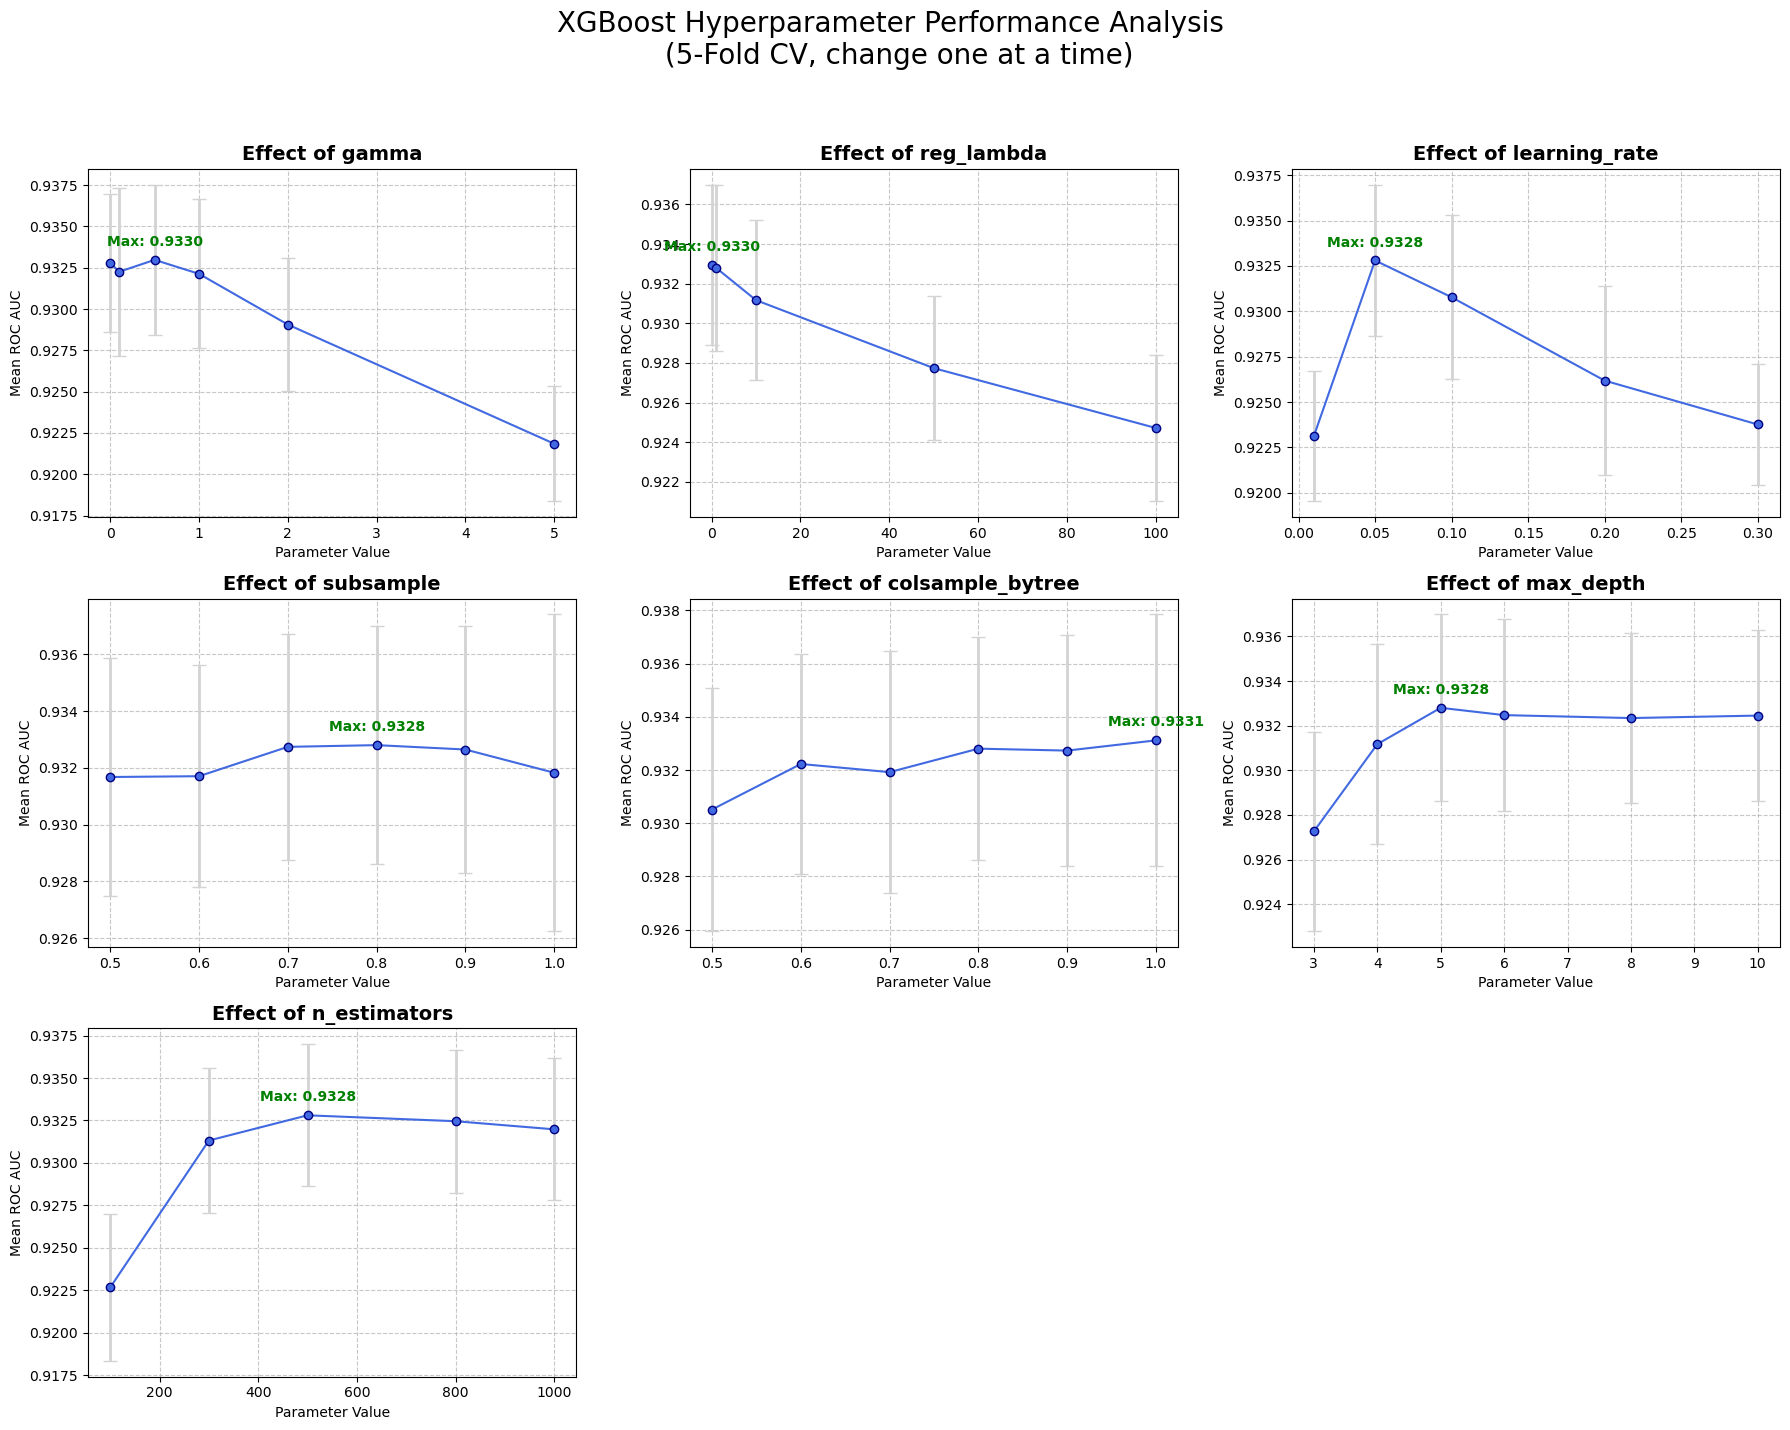

In [95]:
#PLOT RESULTS

# Calculate grid size
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows)) #fix window to fit the plots
fig.suptitle('XGBoost Hyperparameter Performance Analysis \n (5-Fold CV, change one at a time)', fontsize=20)
axes = axes.flatten() # Flatten 2D array to 1D for easy iteration

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]

    # Extract data
    x_vals = data['values']
    y_means = data['means']
    y_errs = data['stds']

    # Plot Error Bar
    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='royalblue', ecolor='lightgray', elinewidth=2, markeredgecolor='navy')
    # error bars are standard deviation on the hyperparameter value (each has number of folds samples)

    # Styling
    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean ROC AUC', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the max value
    max_idx = np.argmax(y_means)
    ax.annotate(f'Max: {y_means[max_idx]:.4f}',
                xy=(x_vals[max_idx], y_means[max_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='green', fontweight='bold')
# delete extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit title
plt.show()

In [ ]:
# TRAINING ON BEST FOUND PARAMETERS
print("FINAL ANALYSIS: COMBINING BEST PARAMETERS")

# Extract best parameters automatically from results
best_found_params = base_params.copy() # Start with base defaults

print("Best parameters found individually:")
for param_name, data in results.items():
    # Find index of maximum Mean AUC
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_score = data['means'][best_idx]

    # Update the best params dictionary
    best_found_params[param_name] = best_value

    print(f"  - {param_name}: {best_value} (AUC: {best_score:.4f})")

print("\nFull configuration for final model:")
print(best_found_params)

# Train on the WHOLE dataset (Production Ready)
print("\nTraining final model on full dataset...")

final_model = xgb.XGBClassifier(**best_found_params)
final_model.fit(X_training, Y_training)


# Final Evaluation on Test Set
print("FINAL TEST SET PERFORMANCE")

# Final predictions
y_pred_grid_xgb = final_model.predict(X_test) # of grid search optimized XGB
y_prob_grid_xgb = final_model.predict_proba(X_test)[:, 1] # of grid search optimized XGB

# Calculate accuracy for more clear results
acc_grid_xgb = accuracy_score(Y_test, y_pred_grid_xgb)
zero_one_grid_xgb = 1 - acc_grid_xgb

# Final AUC score for comparison
roc_auc_grid_xgb = roc_auc_score(Y_test, y_prob_grid_xgb) # of grid search optimized XGB

print(f"Final Test ROC AUC:  {roc_auc_grid_xgb:.4f}")
print(f"Final Test Accuracy: {acc_grid_xgb:.4f}")
print(f"Final Test 0-1 Loss: {zero_one_grid_xgb:.4f} (Error Rate)")

# Number of missclassified events
n_errors = int(zero_one_grid_xgb * len(Y_test))
print(f"\nTotal misclassified samples: {n_errors} out of {len(Y_test)}")

##### "Error" evaluation metric

In [9]:
# not that meaningful for this dataset

``` python
# Base parameters (fixed)
base_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

# Parameters to analyze
params_to_test = {
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'n_estimators': [100, 300, 500, 800, 1000]
}


results = {}
# K Fold setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Analysis (Metric: 0-1 Loss)...")
# loop to change one parameter at the time, keeping standard values for the others
for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        model = xgb.XGBClassifier(**current_params)

        # Changed auc score to accuracy score also for parameter analysis
        scores_acc = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='accuracy')
        scores_error = 1 - scores_acc

        means.append(scores_error.mean())
        stds.append(scores_error.std())

    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")


n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('XGBoost Hyperparameter Analysis (Metric: 0-1 Loss)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    x_vals = data['values']
    y_means = data['means'] # 0-1 loss
    y_errs = data['stds']

    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='firebrick', ecolor='lightgray', elinewidth=2, markeredgecolor='darkred')

    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean 0-1 Loss (Lower is Better)', fontsize=10) # Label aggiornata
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the minumum value
    min_idx = np.argmin(y_means)
    ax.annotate(f'Min Loss: {y_means[min_idx]:.4f}',
                xy=(x_vals[min_idx], y_means[min_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='green', fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Training the whole dataset on the best found parameters and verify the performance
print("FINAL ANALYSIS: COMBINING BEST PARAMETERS (Minimizing 0-1 Loss)")

best_found_params = base_params.copy()

print("Best parameters found individually (Lowest Error):")
for param_name, data in results.items():
    best_idx = np.argmin(data['means'])
    best_value = data['values'][best_idx]
    best_score = data['means'][best_idx]

    best_found_params[param_name] = best_value

    print(f"  - {param_name}: {best_value} (Loss: {best_score:.4f})")

print("\nFull configuration for final model:")
print(best_found_params)

# Verify Performance
print("\nVerifying combined performance with Cross-Validation...")


# rain on WHOLE dataset
print("\nTraining final model on full dataset...")
final_model = xgb.XGBClassifier(**best_found_params)
final_model.fit(X_training, Y_training)

# Final predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Calculate accuracy for more clear results
acc_final = accuracy_score(Y_test, y_pred_final)
zero_one_loss_final = 1 - acc_final

# Final AUC score for comparison
auc_final = roc_auc_score(Y_test, y_prob_final)

print(f"Final Test ROC AUC:  {auc_final:.4f}")
print(f"Final Test Accuracy: {acc_final:.4f}")
print(f"Final Test 0-1 Loss: {zero_one_loss_final:.4f} (Error Rate)")
```

#### Performance analysis for different parameters - grid search (using Optuna)
Strategy (more encompassing): explore points in hyperparameter space in search of optimum combination. Repeat for a number of trials. Optimization is done via [_Tree structured Parzen Estimator_ (TPE) algorithm](https://arxiv.org/pdf/2304.11127), which is implemented in the "Optuna" module.

On each trial, TPE fits one Gaussian Mixture Model (GMM) $l(x)$ (_i.e._ a Kernel Density Estimate of the true probability distribution of hyperparameter values, where the basis consists of Gaussian functions) to the set of hyperparameter values associated with the best objective values; and another GMM $g(x)$ to the remaining hyperparameter values. It chooses the hyperparameter value $x$ that maximizes the ratio $\frac{l(x)}{g(x)}$. It can be proven that maximizing this ratio is (approximately) equivalent to minimizing the quantile-evidence of the model, $\int_{-\infty}^{y^{\gamma}} p(y|x,D) \, dy$ (where $D$ is a set of $x-y$ observations and $y$ an observation of the objective function). The proof relies on Bayes' theorem and on the assumption that a "better" subset of hyperhyperparameters $D^{l}$ exists such that the likelihood $p(x|y,D)$ is equal to $p(x|D^{l})$ for $y$ in the top gamma quantile of observations, $y \leq y^{\gamma}$. Note that the evaluation of the objective (or "loss") function, here, is expensive as it involves training the model with the given hyperparameters: for this reason, it would be computationally unfeasible to use a gradient descent method. Because of the algorithm relying on these successive "splits" in hyperparameter space, it is said to have a "tree-like" structure. 

We use 0-1 loss as metric, as ROC-AUC is not a differentiable loss function, so it can only be used as an evaluation metric.

##### Setup

In [14]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'n_jobs': -1,
        #'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'verbosity': 0,
        'early_stopping_rounds': 50,  # added: early stopping if loss does not improve

        # Define grid search
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 100, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]
        
        model = xgb.XGBClassifier(**param_space, random_state=42)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
    
    return np.mean(scores)

# Study execution
study = optuna.create_study(direction='maximize')

##### Optimization

In [ ]:
i=time.time()
study.optimize(objective, n_trials=50) # ie. run TPE algo for (at most) n_trials times
f=time.time()
# Final results
print("\nBest parameters found with Optuna:")
print(study.best_params)
elapsed=f-i
print(f"Training completed in {elapsed:.1f} seconds.")

In [80]:
study_xgb = study  

We plot the "functional ANOVA" score, _i.e._ the fraction of total variance explained by each hyperparameter, which is readily available in Optuna. We note above all the importance of learning rate.

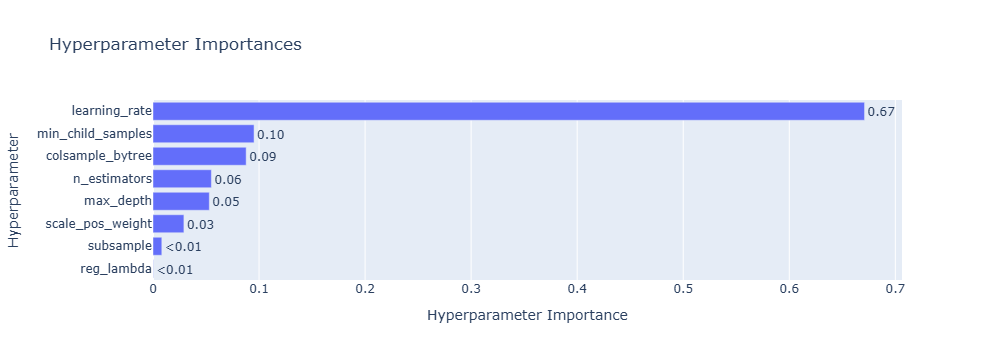

In [104]:
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study).show()

##### Train model on best hyperparameters

In [13]:
final_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'random_state': 42,
    'early_stopping_rounds': 50,   # moved here from fit()
    'eval_metric': 'auc',          # moved here from fit()
    **study.best_params
}

best_model_xgb = xgb.XGBClassifier(**final_params)
best_model_xgb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)], # will be used for early stopping (so, keep even if using CV)
    verbose=False
)

# Test set evaluation
y_pred_xgb = best_model_xgb.predict(X_test)
y_prob_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

roc_auc_clean_xgb = roc_auc_score(Y_test, y_prob_xgb)
acc_clean_xgb = accuracy_score(Y_test, y_pred_xgb)
err_clean_xgb = 1 - acc_clean_xgb

print(f"ROC AUC Score: {auc_opt:.4f}")
print(f"Accuracy Score: {acc_opt:.4f}")
print(f"0-1 Mean Loss: {err_clean_xgb:.4f}")

ROC AUC Score: 0.9350
Accuracy Score: 0.8812
0-1 Mean Loss: 0.1188


Similar accuracy as with one-at-a-time search

### CatBoost

We try another kind of common Gradient Boosting algorithm: "Catboost". With respect to XGBoost and other Boosting alrgorithms, and without going into too much into detail, Catboost:
* typically builds symmetric (oblivious) trees, where the same feature and split condition are used at all nodes of a given depth. XGBoost on the other hand builds asymmetric, level-wise trees, which can lead to more complex and potentially less generalizable structures
* introduces a novel approach called ["Ordered Boosting"](https://arxiv.org/pdf/1706.09516), a permutation-driven alternative designed to prevent the target leakage that can occur in standard gradient boosting algorithms
* is designed with sensible defaults and aims to require less manual tuning to achieve good performance
* can be slower to train due to its ordered boosting mechanism, but it often provides competitive or superior accuracy and is sometimes noted for faster prediction speed once trained.

The theoretical justification for this algorithm is the following. Most implementations of gradient boosting, like XGBoost and LGBoost, face the following statistical issue. A prediction model $F$ obtained after several steps of boosting relies on the targets (labels) of all training examples. This actually leads to a shift of the distribution of $F(x_k)\mid x_k$ for a training example $x_k$ from the distribution of $F(x)\mid x$ for a test example $x$. This finally leads to a _prediction shift_ of the learned model. This problem is a special kind of so-called _target leakage_, _i.e._, the use of information during model training that would not be available at prediction time.

Indeed, in most Boosted models gradients used at each step to compute the new predictor, $F_t$, are estimated using the target values of the same data points the current model $F^{t-1}$ was built on. However, the conditional distribution $F^{t-1}(x_k)\mid x_k$ for a training example $x_k$ is shifted, in general, from the distribution $F^{t-1}(x)\mid x$ for a test example $x$.

The CatBoost algorithm provides a solution to this problem (along with others, as we mentioned) by performing permutations of the training set, such that for calculating the residual on an example, we always use a model trained without it. The practical implementation is not so straightforward, but it is based on this idea.

#### One-at-a-time search, ROC-AUC metric

```python
base_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    # Defaults
    'iterations': 500,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 3,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 1,
    'random_strength': 1    # Adding noise to splits to avoid overfitting
}

# Parameters to analyze
params_to_test = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 10, 20],
    'iterations': [100, 300, 500, 800, 1000],
    'random_strength': [0, 1, 5, 10],
    'bagging_temperature': [0, 0.5, 1, 2]
}

results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        # Initialize CatBoostClassifier
        model = cb.CatBoostClassifier(**current_params)

        # Cross Validation
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    results[param_name] = {'values': param_values, 'means': means, 'stds': stds}
    print("Done.")

# PLots
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('CatBoost Hyperparameter Analysis (5-Fold CV)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    ax.errorbar(data['values'], data['means'], yerr=data['stds'], fmt='-o', color='darkorange', ecolor='bisque')
    ax.set_title(f'Effect of {param_name}', fontweight='bold')
    ax.set_ylabel('Mean ROC AUC')
    ax.grid(True, alpha=0.3)

    max_idx = np.argmax(data['means'])
    ax.annotate(f"Max: {data['means'][max_idx]:.4f}",
                xy=(data['values'][max_idx], data['means'][max_idx]), color='green')

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Final training
print("COMBINING BEST PARAMETERS FOR CATBOOST")

best_found_params = base_params.copy()

for param_name, data in results.items():
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_found_params[param_name] = best_value
    print(f" - {param_name}: {best_value}")


# Initialize the final model architecture
final_model_eval = cb.CatBoostClassifier(**best_found_params)
final_model_eval.fit(X_training,Y_training)
cat_bestpar= best_found_params.copy()
y_pred = final_model_eval.predict(X_test)
test_acc = accuracy_score(Y_test, y_pred)

print(f"\nRESULTS (5-Fold CV):")
print(f"Final Mean Accuracy: {test_acc:.2f}%")
```

#### Grid search (Optuna), ROC-AUC metric

The hyperparameters involved in this model are:

* `iterations`: number of boosting rounds (trees); more trees increase capacity but may overfit
*  `learning_rate`: same as XGBoost
* `depth`: same as `max_depth` for XGBoost
* `l2_leaf_reg`: same as `lambda` for XGBoost
* `random_strength`: strength of Gaussian noise added to split scores (_i.e._, the reduction in loss); acts as a regularizer by introducing randomness during tree construction
* `bootstrap_type` (Bayesian) and `bagging_temperature`: we use Bayesian bootstrap with a temperature parameter; higher temperature increases sample-weight randomness, decorrelating trees (see below)
* `colsample_bylevel`: same as `colsample_bytree` for XGBoost
* `min_data_in_leaf`: same as `min_child_weight` for XGBoost
* `scale_pos_weight`: same as for XGBoost

_Bootstrapping_ is a concept similar to subsapling, wich proved effective in practice. It assigns random weights to samples via a certain process. This is usually the heaviest part of Catboost's computation.

For Bayesian bootstrapping, each example is assigned a weight $(-\text{log}(u))^t$ where $u$ is sampled from a uniform distribution on $]0,1[$ and $t$ is the set bagging "temperature". Higher "temperature" increases weight randomness leading to more tree decorrelation, but slower training.

In [29]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'verbose': False,
        'random_seed': 42,

        # Parameters to optimize
        'iterations': trial.suggest_int('iterations', 100, 1000), # or: 100, 1000
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.01, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        'bootstrap_type': 'Bayesian', # or: 'Bernoulli'
        #'subsample': trial.suggest_float('subsample', 0.5, 1.5),     
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
        
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 1.5, log=True),

        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 30)
    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]
        
        model = cb.CatBoostClassifier(**param_space)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], early_stopping_rounds= 50, verbose=False)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
    
    return np.mean(scores)

# Study execution
study = optuna.create_study(direction='maximize')

In [30]:
i=time.time()
study.optimize(objective, n_trials=50) # ie. run TPE algo for (at most) n_trials times
f=time.time()
# Final results
print("\nBest parameters found with Optuna:")
print(study.best_params)
elapsed=f-i
print(f"Training completed in {elapsed:.1f} seconds.")


Best parameters found with Optuna:
{'iterations': 741, 'learning_rate': 0.03307754248350243, 'depth': 6, 'l2_leaf_reg': 0.2820878656937367, 'random_strength': 1.5204812526686067, 'bagging_temperature': 0.13327237883069198, 'scale_pos_weight': 1.2380297131407831, 'colsample_bylevel': 0.8106976441400421, 'min_data_in_leaf': 7}
1220.1043202877045


In [31]:
 # Training on whole set
final_model_cb = cb.CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    task_type='CPU',
    random_seed=42,
    verbose=False,
    **study.best_params
)

final_model_cb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)],
    early_stopping_rounds=50,
    verbose=False
)

# Test set evaluation
y_pred_cb = final_model_cb.predict(X_test)
y_prob_cb = final_model_cb.predict_proba(X_test)[:, 1]
roc_auc_clean_cb=roc_auc_score(Y_test, y_prob_cb)
acc_clean_cb=accuracy_score(Y_test, y_pred_cb)
err_clean_cb=1-acc_clean_cb

print(f"CATBOOST FINAL PERFORMANCE (TEST SET)")
print(f"ROC AUC:  {roc_auc_clean_cb:.4f}")
print(f"Accuracy: {acc_clean_cb:.4f}")
print(f"0-1 Loss: {err_clean_cb:.4f}")

CATBOOST FINAL PERFORMANCE (TEST SET)
ROC AUC:  0.9381
Accuracy: 0.8866
0-1 Loss: 0.1134


In [ ]:
study_cb = study

In [ ]:
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study).show()

### LightGMB

LightGBM, short for Light Gradient-Boosting Machine, is another gradient boosting library based on decision trees. The development focus however is on performance and scalability. A features towards faster training is, for example, retaining all large‑gradient instances while randomly downsampling small‑gradient ones.

LightGBM is typically the fastest to train among major boosting libraries, and its default settings often perform well without extensive tuning.

The hyperparameters involved in this model are:

- `n_estimators`: same as `iterations` in CatBoost
- `learning_rate`: same as before
- `max_depth`: same as before
- `reg_lambda`: same as before
- `min_child_samples`: same as before
- `subsample`: same as before
- `colsample_bytree`: same as before
- `scale_pos_weight`: same as before

#### One-at-a-time search

```python
# Base parameters
base_params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'metric': 'auc',
    'verbosity': -1,  # Just to remove print of errors
    # Defaults for parameters not to be tested
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'num_leaves': 31,
    'bagging_fraction': 0.8,  # Equivalent to subsample
    'bagging_freq': 5,        # Necessary when using bagging_fraction
    'feature_fraction': 0.8,  # Equivalent to colsample_bytree
    'min_gain_to_split': 0,   # Equivalent to gamma
    'lambda_l2': 1            # Equivalent to reg_lambda
}

# Parameters to analyze
params_to_test = {
    'min_gain_to_split': [0, 0.1, 0.5, 1, 2, 5],
    'lambda_l2': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'bagging_fraction': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'feature_fraction': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'num_leaves': [15, 31, 63, 127, 255],
    'n_estimators': [100, 300, 500, 800, 1000]
}

results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        # Use LGBMClassifier
        model = lgb.LGBMClassifier(**current_params)
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")

# --- PLOTTING SECTION (Same logic as yours) ---
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('LightGBM Hyperparameter Performance Analysis (5-Fold CV)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    x_vals = [str(v) for v in data['values']] # Convert to string for better x-axis spacing
    y_means = data['means']
    y_errs = data['stds']

    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='forestgreen', ecolor='lightgray', elinewidth=2, markeredgecolor='darkgreen')

    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean ROC AUC', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    max_idx = np.argmax(y_means)
    ax.annotate(f'Max: {y_means[max_idx]:.4f}',
                xy=(max_idx, y_means[max_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='red', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- FINAL TRAINING ON BEST FOUND PARAMETERS ---
print("\nFINAL ANALYSIS: COMBINING BEST PARAMETERS")
best_found_params = base_params.copy()

for param_name, data in results.items():
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_found_params[param_name] = best_value
    print(f"  - {param_name}: {best_value} (AUC: {data['means'][best_idx]:.4f})")

print("\nTraining final LightGBM model...")
final_model = lgb.LGBMClassifier(**best_found_params)
final_model.fit(X_training, Y_training)

# Evaluation
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

auc_final = roc_auc_score(Y_test, y_prob_final)
acc_final = accuracy_score(Y_test, y_pred_final)

print(f"\nFinal Test ROC AUC:  {auc_final:.4f}")
print(f"Final Test Accuracy: {acc_final:.4f}")
```

#### Grid search (Optuna), ROC-AUC metric

In [38]:
### LightGBM Optimisation with Optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    param_space = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': -1,

        # Parameters to optimize
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10.0, log=True),

        # Fixed parameters for bagging
        'bagging_freq': 1,   # perform bagging at every iteration
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = lgb.LGBMClassifier(**param_space)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50)]#, lgb.log_evaluation(0)]
        )
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study = optuna.create_study(direction='maximize')

i=time.time()
study.optimize(objective, n_trials=50)
f=time.time()
elapsed=f-i
print(f"Training completed in {elapsed:.1f} seconds.")

# Final results
print("Best parameters found with Optuna:")
print(study.best_params)

# Training on whole set
final_model_lgb = lgb.LGBMClassifier(**study.best_params, random_state=42)
final_model_lgb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Test set evaluation
y_pred_lgb = final_model_lgb.predict(X_test)
y_prob_lgb = final_model_lgb.predict_proba(X_test)[:, 1]
roc_auc_clean_lgb=roc_auc_score(Y_test, y_prob_lgb)
acc_clean_lgb=accuracy_score(Y_test, y_pred_lgb)
err_clean_lgb=1-acc_clean_lgb

print(f"LIGHTGBM FINAL PERFORMANCE (TEST SET)")
print(f"ROC AUC:  {roc_auc_clean_lgb:.4f}")
print(f"Accuracy: {acc_clean_lgb:.4f}")
print(f"0-1 Loss: {err_clean_lgb:.4f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[789]	valid_0's auc: 0.928223


C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[790]	valid_0's auc: 0.928843


C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[790]	valid_0's auc: 0.935236


...

C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Did not meet early stopping. Best iteration is:
[376]	valid_0's auc: 0.931861
445.9784893989563
Best parameters found with Optuna:
{'n_estimators': 648, 'learning_rate': 0.054297553521490086, 'max_depth': 12, 'reg_lambda': 0.0111354520659252, 'min_child_samples': 4, 'subsample': 0.6123269588065194, 'colsample_bytree': 0.8340496040796322, 'scale_pos_weight': 1.5523050475722626}


C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LIGHTGBM FINAL PERFORMANCE (TEST SET)
ROC AUC:  0.9347
Accuracy: 0.8839
0-1 Loss: 0.1161


C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best parameters found with Optuna:
{'n_estimators': 648, 'learning_rate': 0.054297553521490086, 'max_depth': 12, 'reg_lambda': 0.0111354520659252, 'min_child_samples': 4, 'subsample': 0.6123269588065194, 'colsample_bytree': 0.8340496040796322, 'scale_pos_weight': 1.5523050475722626}



LIGHTGBM FINAL PERFORMANCE (TEST SET)
ROC AUC:  0.9347
Accuracy: 0.8839
0-1 Loss: 0.1161

In [ ]:
study_lgb = study

In [ ]:
optuna.visualization.plot_param_importances(study).show()

### Conclusions

In the following plot we summarize the performance of the three tuned models.

In [ ]:
models = ['RandomForest', 'GradientBoost', 'LightGBM', 'XGBoost', 'CatBoost']

C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



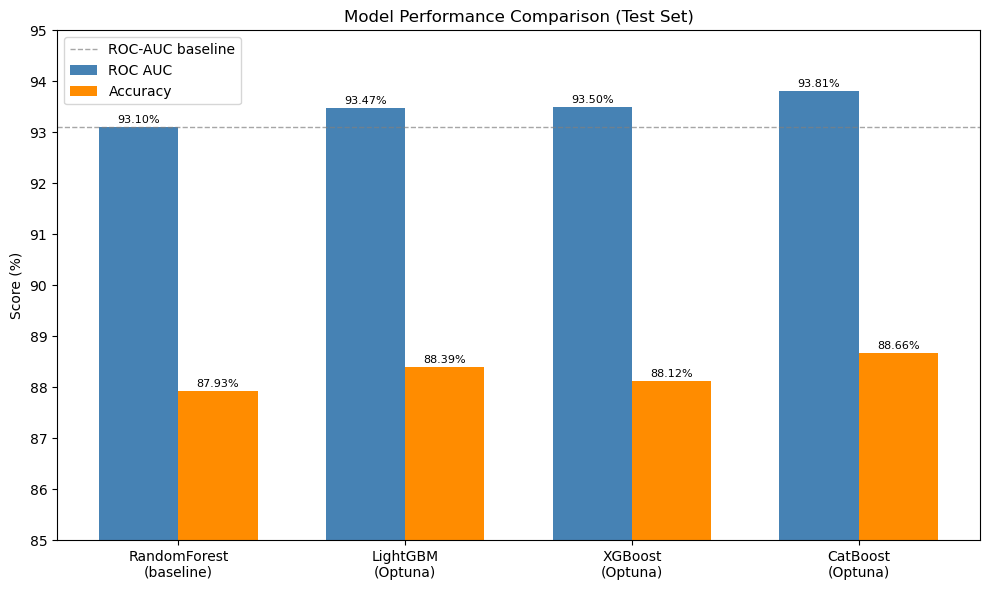

In [103]:
aucs = [100 * roc_auc_clean_rf,
        100 * roc_auc_clean_gbm,
        100 * roc_auc_clean_lgb,
        100 * roc_auc_clean_xgb,
        100 * roc_auc_clean_cb]

accs = [100 * acc_clean_rf,
        100 * acc_clean_gbm,
        100 * acc_clean_lgb,
        100 * acc_clean_xgb,
        100 * acc_clean_cb]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, aucs, width, label='ROC AUC', color='steelblue')
bars2 = ax.bar(x + width/2, accs, width, label='Accuracy', color='darkorange')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison (Test Set)')
ax.set_xticks(x)
ax.set_yticks(np.arange(84,96))
ax.set_xticklabels(models)
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
ax.set_ylim(85, 95)
ax.axhline(y=100 * roc_auc_clean_rf, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='ROC-AUC baseline')
ax.legend()
plt.tight_layout()
plt.show()

We now plot the ROC curve, the area under which coincides with the evaluation metric we used, _i.e._ the ROC-AUC. Recall that the larger the area, the better; an area of 0.5 corresponds to a random guess, and of 1 to a perfect classification. We zoom on the relevant points on this curve, _i.e._ those where the probability ofa false positive is under the threshold of 20%, as would be the case for some scientific experiments.

C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



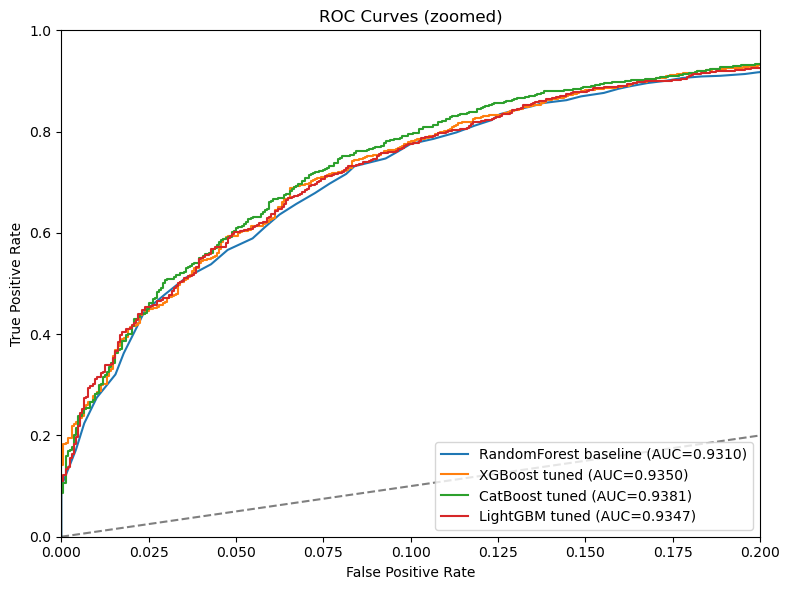

In [93]:
fig, ax = plt.subplots(figsize=(8,6))
for name, y_prob in [('RandomForest baseline', y_prob_rf),
                     ('GradientBoost tuned', y_prob_gbm),
                     ('XGBoost tuned', y_prob_xgb),
                     ('CatBoost tuned', y_prob_cb),
                     ('LightGBM tuned', y_prob_lgb)]:
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(Y_test, y_prob):.4f})') # computes it again

ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (zoomed)')
ax.set_xlim(0., 0.2)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

We now plot Optuna's optimization history for the three models. We can observe how fluctuations in ROC-AUC metric become smaller while progressing with iterations, which indicates an effective exploration of the .

NameError: name 'study_cb' is not defined

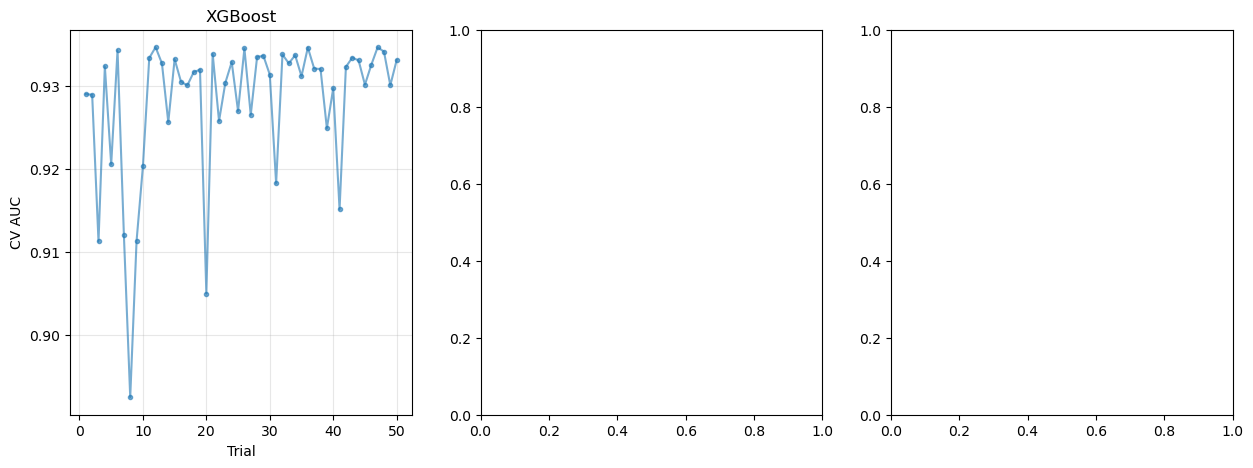

In [81]:
from optuna.visualization import plot_optimization_history

def plot_convergence(study, name, ax):
    trials = study.trials
    values = [t.value for t in trials if t.state == optuna.trial.TrialState.COMPLETE]
    ax.plot(range(1, len(values)+1), values, marker='.', alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV AUC')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_convergence(study_gbm, 'GradientBoost', axes[0, 0])
plot_convergence(study_xgb, 'XGBoost', axes[0, 1])
plot_convergence(study_cb,  'CatBoost',    axes[1, 0])
plot_convergence(study_lgb, 'LightGBM',    axes[1, 1])
fig.suptitle('Optuna Optimisation History')
plt.tight_layout()
plt.show()

We also plot the SHAP score for the best model, _i.e._ the XGBoost tuned model.

SHAP values measure how much each feature pushes a prediction away from the average prediction. For tree models, TreeSHAP computes these by tracking how splits change the expected output as it traverses each path, averaging the feature's contribution over all trees. The result is an additive explanation where each feature's SHAP value plus the baseline equals the model's prediction for that instance. (Therefore: one point = one feature of one sample from test set, from the positive class).

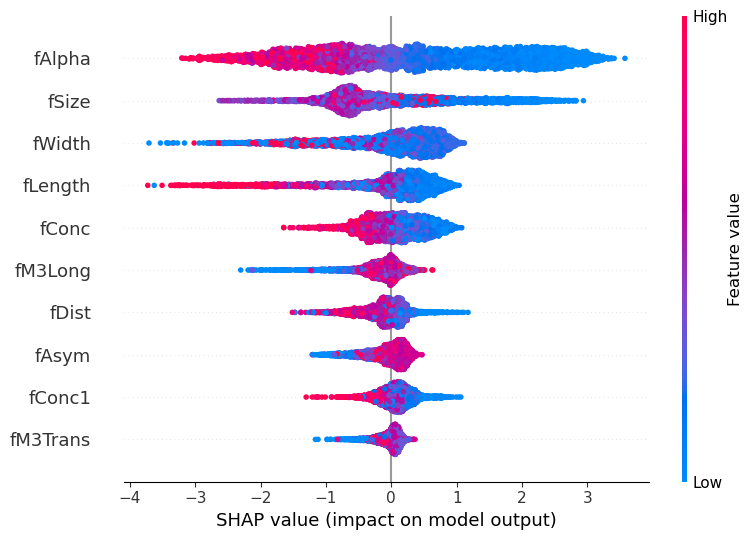

In [84]:
explainer = shap.TreeExplainer(best_model_xgb) # ie. tuned XGBoost
shap_values = explainer.shap_values(X_test)  # subsample for speed
shap.summary_plot(shap_values, X_test, feature_names=['fLength','fWidth','fSize','fConc','fConc1','fAsym','fM3Long','fM3Trans','fAlpha','fDist'])

## Neural network comparison

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

In [19]:
def build_model(input_dim,
                hidden_units=(64, 32),   # tuple of units per hidden layer – tune length & sizes
                dropout_rate=0.4,
                l2_reg=1e-4,
                noise_std=0.02,          # try 0.0 (no noise) or small value
                learning_rate=1e-3):
    model = Sequential()
    model.add(GaussianNoise(noise_std, input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(Dense(units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='binary_crossentropy',
        metrics='val_auc' #[AUC(curve='ROC')]   # AUC class with curve parameter
    )
    return model

In [20]:
X_training.shape

(10699, 10)

In [21]:
simple_nn=build_model(input_dim=10)

C:\Users\Libero\anaconda3\Lib\site-packages\keras\src\layers\regularization\gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
simple_nn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gaussian_noise_2 (GaussianNoise)     │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 192 (768.00 B)

In [23]:
#dense, dropout, dense, dropout, dense

In [24]:
scaler = StandardScaler() # standardize input data beforehand
X_training_sc = scaler.fit_transform(X_training)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [28]:
early_stop = EarlyStopping(
    monitor='val_auc' #AUC(curve='ROC'),
    mode='max',
    patience=10,
    restore_best_weights=True
)

In [29]:
i=time.time()
history = simple_nn.fit(
    X_training_sc, Y_training,
    validation_data=(X_val_sc, Y_val),
    epochs=200, # but early stopping 
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
f=time.time()
elapsed=f-i
print(f"Training completed in {elapsed:.1f} seconds.")

C:\Users\Libero\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `<AUC name=auc_3>` which is not available. Available metrics are: auc_1,loss,val_auc_1,val_loss
  current = self.get_monitor_value(logs)


465.3158242702484


In [31]:
test_loss, test_auc = simple_nn.evaluate(X_test_sc, Y_test, verbose=0)
print(f"\nTest ROC AUC: {test_auc:.4f}")


Test ROC AUC: 0.9363


### Robustness of tuned boosted models to worse training datasets

#### Reduced size of dataset

In [ ]:
# --- Learning Curve: Test ROC‑AUC vs Training Set Size ---
# Uses tuned Optuna params for XGBoost, CatBoost, LightGBM

# Best params from  Optuna studies (hardcoded for reproducibility)
xgb_best = {
    'booster': 'gbtree', 'objective': 'binary:logistic', 'n_jobs': -1,
    'tree_method': 'hist', 'random_state': 42, 'eval_metric': 'auc',
    'early_stopping_rounds': 50, 'verbosity': 0,
    **study_xgb.best_params
}
cat_best = {
    'loss_function': 'Logloss', 'eval_metric': 'AUC', 'task_type': 'CPU',
    'verbose': False, 'random_seed': 42, 'early_stopping_rounds': 50,
    **study_cb.best_params
}
lgb_best = {
    'boosting_type': 'gbdt', 'objective': 'binary', 'metric': 'auc',
    'n_jobs': -1, 'random_state': 42, 'verbosity': -1,
    'bagging_freq': 1,
    **study_lgb.best_params
}

In [ ]:
# Fractions of the training set to use
fracs = np.linspace(0.1, 1.0, 10)
auc_xgb, auc_cat, auc_lgb = [], [], []
i=time.time()

for frac in fracs:
    # Subsample the training data (stratified)
    X_sub, _, y_sub, _ = train_test_split(
        X_training, Y_training, train_size=frac, stratify=Y_training, random_state=42
    )
    # Further split off a validation subset (10%) for early stopping
    X_tr, X_val_sub, y_tr, y_val_sub = train_test_split(
        X_sub, y_sub, test_size=0.1, stratify=y_sub, random_state=42
    )
    
    # XGBoost
    model_xgb = xgb.XGBClassifier(**xgb_best)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)], verbose=False)
    auc_xgb.append(roc_auc_score(Y_test, model_xgb.predict_proba(X_test)[:, 1]))

    # CatBoost
    model_cat = cb.CatBoostClassifier(**{k:v for k,v in cat_best.items() if k != 'early_stopping_rounds'})  # clean up
    model_cat.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)], early_stopping_rounds=50, verbose=False)
    auc_cat.append(roc_auc_score(Y_test, model_cat.predict_proba(X_test)[:, 1]))

    # LightGBM
    model_lgb = lgb.LGBMClassifier(**lgb_best)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb.append(roc_auc_score(Y_test, model_lgb.predict_proba(X_test)[:, 1]))

    # Neural network baseline
    simple_nn.evaluate(X_test_sc, Y_test, verbose=0)

f=time.time()
elapsed=f-i
print(f"Noisy dataset experiment completed in {elapsed:.1f} seconds.")

In [ ]:
# Plot
train_sizes = [int(frac * len(Y_training)) for frac in fracs]
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, auc_xgb, 'o-', label='XGBoost')
plt.plot(train_sizes, auc_cat, 's-', label='CatBoost')
plt.plot(train_sizes, auc_lgb, 'd-', label='LightGBM')
plt.xlabel('Training set size')
plt.ylabel('Test ROC‑AUC')
plt.title('Learning Curve (fixed Optuna params)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Noisy dataset

In [ ]:
# ---- Robustness to Gaussian feature noise ----

def rigorous_augmentation(X, y, noise_level=0.01, multiplier=2):
    """Add Gaussian noise (scaled by feature std) and optionally multiply the dataset."""
    X_augmented_list = [X]
    y_augmented_list = [y]
    stds = np.std(X, axis=0)
    for _ in range(multiplier - 1):
        noise = np.random.normal(0, stds * noise_level, size=X.shape)
        X_noisy = X + noise
        X_augmented_list.append(X_noisy)
        y_augmented_list.append(y)
    return np.vstack(X_augmented_list), np.concatenate(y_augmented_list)

In [ ]:
noise_levels = np.linspace(0., 1., 10)
auc_drop_xgb, auc_drop_cb, auc_drop_lgb, auc_drop_nn = [], [], [], []

# Clean baselines (already computed earlier in the notebook)
clean_auc_xgb = roc_auc_clean_xgb
clean_auc_cb  = roc_auc_clean_cb
clean_auc_lgb = roc_auc_clean_lgb

i=time.time()
for p in noise_levels:
    X_aug, y_aug = rigorous_augmentation(X_training, Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_best)
    m_xgb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)], verbose=False)
    auc_xgb = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
    auc_drop_xgb.append(clean_auc_xgb - auc_xgb)

    # CatBoost (early_stopping_rounds belongs to fit, not constructor)
    cat_params_clean = {k: v for k, v in cat_best.items() if k != 'early_stopping_rounds'}
    m_cb = cb.CatBoostClassifier(**cat_params_clean)
    m_cb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)],
             early_stopping_rounds=50, verbose=False)
    auc_cb = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
    auc_drop_cb.append(clean_auc_cb - auc_cb)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best)
    m_lgb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
    auc_drop_lgb.append(clean_auc_lgb - auc_lgb)

    # Neural network (fresh model each time)
    # Scale the augmented training data and the original test set
    scaler_noise = StandardScaler()
    X_aug_sc = scaler_noise.fit_transform(X_aug)
    X_test_sc = scaler_noise.transform(X_test)          # always the same clean test set
    X_val_sc_nn = scaler_noise.transform(X_val)         # for early stopping, use clean val? 
    # Note: Using clean validation set for early stopping is fine; it's small and consistent.

    nn_model = build_model(input_dim=10)   # creates a new compiled model
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)
    nn_model.fit(X_aug_sc, y_aug,
                 validation_data=(X_val_sc_nn, Y_val),
                 epochs=200, batch_size=32, callbacks=[early_stop], verbose=0)
    auc_nn = nn_model.evaluate(X_test_sc, Y_test, verbose=0)[1]   # returns [loss, auc]
    # We need the clean NN AUC baseline from the original training (already computed as test_auc)
    clean_auc_nn = test_auc   # from the earlier cell where we trained on clean data
    auc_drop_nn.append(clean_auc_nn - auc_nn)

    print(f"Noise level {p:.2f} completed")
f=time.time()
elapsed=f-i
print(f"Feature‑noise robustness experiment finished in {elapsed:.1f} seconds.")

In [ ]:
# Plot AUC degradation
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, auc_drop_xgb, 'o-', label='XGBoost')
plt.plot(noise_levels, auc_drop_cb, 's-', label='CatBoost')
plt.plot(noise_levels, auc_drop_lgb, 'd-', label='LightGBM')
plt.plot(noise_levels, auc_drop_nn, 'v-', label='Neural Net')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Gaussian noise level (relative to feature std)')
plt.ylabel('Clean AUC − Noisy AUC')
plt.title('Impact of Feature Noise on Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Noisy labels

In [ ]:
gbm_best = {**study_gbm.best_params}   # no early_stopping_rounds here (handled by fit)

In [ ]:
# ---- Robustness to label noise (flipped labels) ----

def inject_label_noise(y, noise_level=0.1):
    """Randomly flip a fraction of labels to the opposite class."""
    y_noisy = np.array(y).copy()
    n_samples = len(y_noisy)
    n_to_flip = int(noise_level * n_samples)
    indices_to_flip = np.random.choice(n_samples, n_to_flip, replace=False)
    unique_classes = np.unique(y_noisy)
    for idx in indices_to_flip:
        original_label = y_noisy[idx]
        possible_labels = [c for c in unique_classes if c != original_label]
        y_noisy[idx] = np.random.choice(possible_labels)
    return y_noisy


noise_levels = np.linspace(0, 0.2, 10)
auc_drop_xgb, auc_drop_cb, auc_drop_lgb, auc_drop_nn = [], [], [], []

# clean baselines (already computed earlier in the notebook)
clean_auc_xgb = roc_auc_clean_xgb
clean_auc_cb  = roc_auc_clean_cb
clean_auc_lgb = roc_auc_clean_lgb
clean_auc_nn  = test_auc  

i=time.time()
for p in noise_levels:
    y_noisy = inject_label_noise(Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_best)
    m_xgb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)], verbose=False)
    auc_xgb = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
    auc_drop_xgb.append(clean_auc_xgb - auc_xgb)

    # CatBoost (early_stopping_rounds in fit, remove from params if present)
    cat_params_clean = {k: v for k, v in cat_best.items() if k != 'early_stopping_rounds'}
    m_cb = cb.CatBoostClassifier(**cat_params_clean)
    m_cb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)],
             early_stopping_rounds=50, verbose=False)
    auc_cb = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
    auc_drop_cb.append(clean_auc_cb - auc_cb)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best)
    m_lgb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
    auc_drop_lgb.append(clean_auc_lgb - auc_lgb)

    # Neural network (re‑train from scratch on noisy labels)
    nn_model = build_model(input_dim=10)
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)
    nn_model.fit(X_training_sc, y_noisy,
                 validation_data=(X_val_sc, Y_val),
                 epochs=200, batch_size=32, callbacks=[early_stop], verbose=0)
    auc_nn = nn_model.evaluate(X_test_sc, Y_test, verbose=0)[1]
    auc_drop_nn.append(clean_auc_nn - auc_nn)

    print(f"Label noise {p:.2f} completed")

f=time.time()
print(f"Label‑noise robustness experiment finished in {elapsed:.1f} seconds.")

In [ ]:
# Plot AUC drop
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, auc_drop_xgb, 'o-', label='XGBoost', color='blue')
plt.plot(noise_levels, auc_drop_cb, 's-', label='CatBoost', color='green')
plt.plot(noise_levels, auc_drop_lgb, 'd-', label='LightGBM', color='orange')
plt.plot(noise_levels, auc_drop_nn, 'v-', label='Neural Net', color='purple')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Fraction of flipped labels')
plt.ylabel('Clean AUC – Noisy AUC')
plt.title('Impact of Label Noise on Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## (DUMPS)

In [ ]:
# ============================================================
# DUMPS – Save all important objects to avoid retraining
# ============================================================

# --- Trained models ---
joblib.dump(rf,               'rf_baseline.pkl')
joblib.dump(best_gbm,         'gbm_tuned.pkl')
joblib.dump(best_model_xgb,   'xgb_tuned.pkl')
joblib.dump(final_model_cb,   'catboost_tuned.pkl')
joblib.dump(final_model_lgb,  'lightgbm_tuned.pkl')

# Keras model – save in .h5 format (joblib not reliable for Keras)
simple_nn.save('nn_model.h5')
# Also save the training history (can be useful for plotting learning curves)
joblib.dump(history, 'nn_history.pkl')

# --- Optuna studies ---
joblib.dump(study_gbm, 'study_gbm.pkl')
joblib.dump(study_xgb, 'study_xgb.pkl')
joblib.dump(study_cb,  'study_cb.pkl')
joblib.dump(study_lgb, 'study_lgb.pkl')

# --- Data arrays (original and scaled) ---
# The raw splits might be needed if you want to re-run with different settings.
joblib.dump((X_training, Y_training), 'training_data.pkl')
joblib.dump((X_test, Y_test),         'test_data.pkl')
joblib.dump((X_val, Y_val),           'validation_data.pkl')
# Scaled versions (for the neural network)
joblib.dump((X_training_sc, X_val_sc, X_test_sc), 'scaled_data.pkl')
joblib.dump(scaler, 'scaler.pkl')

# --- Clean performance metrics (ROC‑AUC, accuracy, error) ---
clean_metrics = {
    'rf':  {'auc': roc_auc_clean_rf,  'acc': acc_clean_rf,  'err': err_clean_rf},
    'gbm': {'auc': roc_auc_clean_gbm, 'acc': acc_clean_gbm, 'err': err_clean_gbm},
    'xgb': {'auc': roc_auc_clean_xgb, 'acc': acc_clean_xgb, 'err': err_clean_xgb},
    'cb':  {'auc': roc_auc_clean_cb,  'acc': acc_clean_cb,  'err': err_clean_cb},
    'lgb': {'auc': roc_auc_clean_lgb, 'acc': acc_clean_lgb, 'err': err_clean_lgb},
    'nn':  {'auc': test_auc}  # NN only AUC was stored
}
joblib.dump(clean_metrics, 'clean_metrics.pkl')

# --- Best hyperparameters (dictionaries) ---
joblib.dump({
    'xgb': xgb_best,
    'cat': cat_best,
    'lgb': lgb_best,
    'gbm': study_gbm.best_params
}, 'best_params.pkl')

# --- Learning curve results ---
joblib.dump({
    'train_sizes': train_sizes,
    'auc_xgb': auc_xgb,
    'auc_cat': auc_cat,
    'auc_lgb': auc_lgb
}, 'learning_curve_results.pkl')

# --- Robustness to Gaussian feature noise ---
joblib.dump({
    'noise_levels_feature': noise_levels,   # from the noisy dataset section
    'auc_drop_xgb_feature': auc_drop_xgb,
    'auc_drop_cb_feature': auc_drop_cb,
    'auc_drop_lgb_feature': auc_drop_lgb,
    'auc_drop_nn_feature': auc_drop_nn
}, 'feature_noise_results.pkl')

# --- Robustness to label noise ---
joblib.dump({
    'noise_levels_label': noise_levels,     # from the noisy labels section (0 to 0.2)
    'auc_drop_xgb_label': auc_drop_xgb,
    'auc_drop_cb_label': auc_drop_cb,
    'auc_drop_lgb_label': auc_drop_lgb,
    'auc_drop_nn_label': auc_drop_nn
}, 'label_noise_results.pkl')

# --- SHAP explainer (if you want to reproduce plots) ---
joblib.dump(explainer, 'shap_explainer.pkl')
joblib.dump(shap_values, 'shap_values.pkl')  # computed on X_test

# --- Class balance ratio ---
joblib.dump(ratio, 'class_ratio.pkl')

# --- XGBoost one-at-a-time search results (the `results` dict) ---
joblib.dump(results, 'xgb_one_at_a_time_results.pkl')

# --- Final model predictions (for later ROC / confusion matrix) ---
joblib.dump({
    'y_pred_rf': y_pred_rf,
    'y_prob_rf': y_prob_rf,
    'y_pred_gbm': y_pred_gbm,
    'y_prob_gbm': y_prob_gbm,
    'y_pred_xgb': y_pred_xgb,
    'y_prob_xgb': y_prob_xgb,
    'y_pred_cb': y_pred_cb,
    'y_prob_cb': y_prob_cb,
    'y_pred_lgb': y_pred_lgb,
    'y_prob_lgb': y_prob_lgb,
}, 'test_predictions.pkl')

print("All objects saved successfully.")